### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [84]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


In [85]:
# Punto 1

top10 = df.sort_values(by='total_litres_of_pure_alcohol', ascending=False).head(10) # in base alla colonna, ordino in maniera decrescente e visualizzo primi 10
top10[['country', 'total_litres_of_pure_alcohol']] # per visualizzare Paese e consumo alcol per litro

,country,total_litres_of_pure_alcohol
15,Belarus,14.4
98,Lithuania,12.9
3,Andorra,12.4
68,Grenada,11.9
61,France,11.8
45,Czech Republic,11.8
141,Russian Federation,11.5
99,Luxembourg,11.4
155,Slovakia,11.4
81,Ireland,11.4


In [86]:
# punto 2

media_birra = df['beer_servings'].mean()
media_vino = df['wine_servings'].mean()
media_distillati = df['spirit_servings'].mean()

media_birra, media_vino, media_distillati

(np.float64(106.16062176165804),
 np.float64(49.45077720207254),
 np.float64(80.99481865284974))

In [87]:
# Punto 3

df['alcohol_index'] = (df['beer_servings'] + df['wine_servings'] + df['spirit_servings']) / 3 # ritorna una series il cui valore è la somma delle colonne fratto 3
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
0,Afghanistan,0,0,0,0.0,0.000000
1,Albania,89,132,54,4.9,91.666667
2,Algeria,25,0,14,0.7,13.000000
3,Andorra,245,138,312,12.4,231.666667
4,Angola,217,57,45,5.9,106.333333
...,...,...,...,...,...,...
188,Venezuela,333,100,3,7.7,145.333333
189,Vietnam,111,2,1,2.0,38.000000
190,Yemen,6,0,0,0.1,2.000000
191,Zambia,32,19,4,2.5,18.333333


In [88]:
# punto 4
df.sort_values(by='alcohol_index', ascending=False).head(1) # Ordino in base alla colonna, in maniera decrescente e prendo primo valore

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
3,Andorra,245,138,312,12.4,231.666667


In [89]:
# Punto 5

birra100 = df[df['beer_servings'] > 100] # filtro in base a condizione >100
birra100[['country', 'beer_servings']] # per visualizzare Paesi che consumano piu di 100 birre all'anno

,country,beer_servings
3,Andorra,245
4,Angola,217
5,Antigua & Barbuda,102
6,Argentina,193
8,Australia,261
...,...,...
182,United Kingdom,219
184,USA,249
185,Uruguay,115
188,Venezuela,333


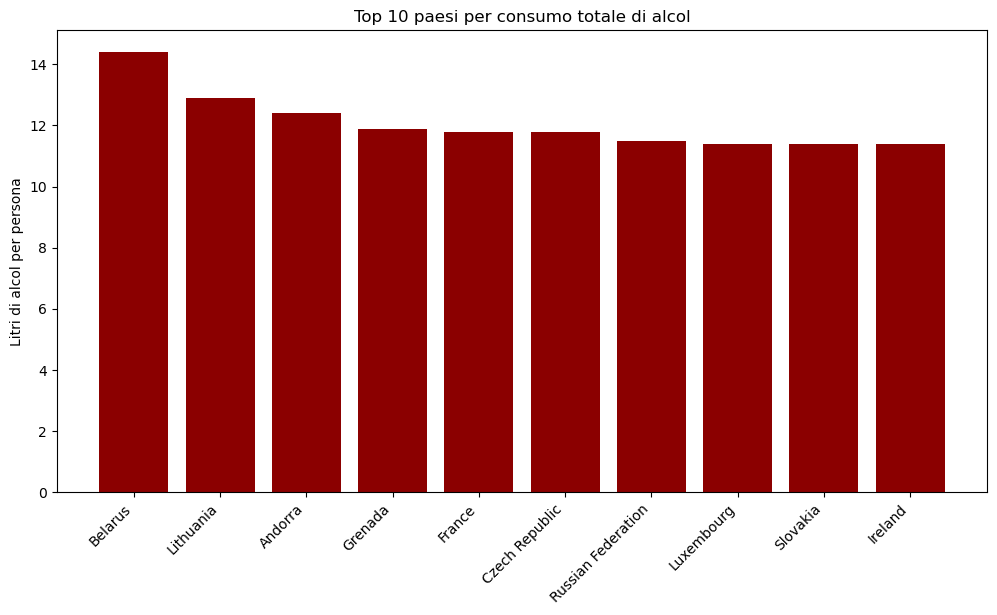

In [90]:
# Bar chart top 10 per consumo totale di alcol per Paese
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(top10['country'], top10['total_litres_of_pure_alcohol'], color='darkred')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Litri di alcol per persona")
plt.title("Top 10 paesi per consumo totale di alcol")
plt.show()

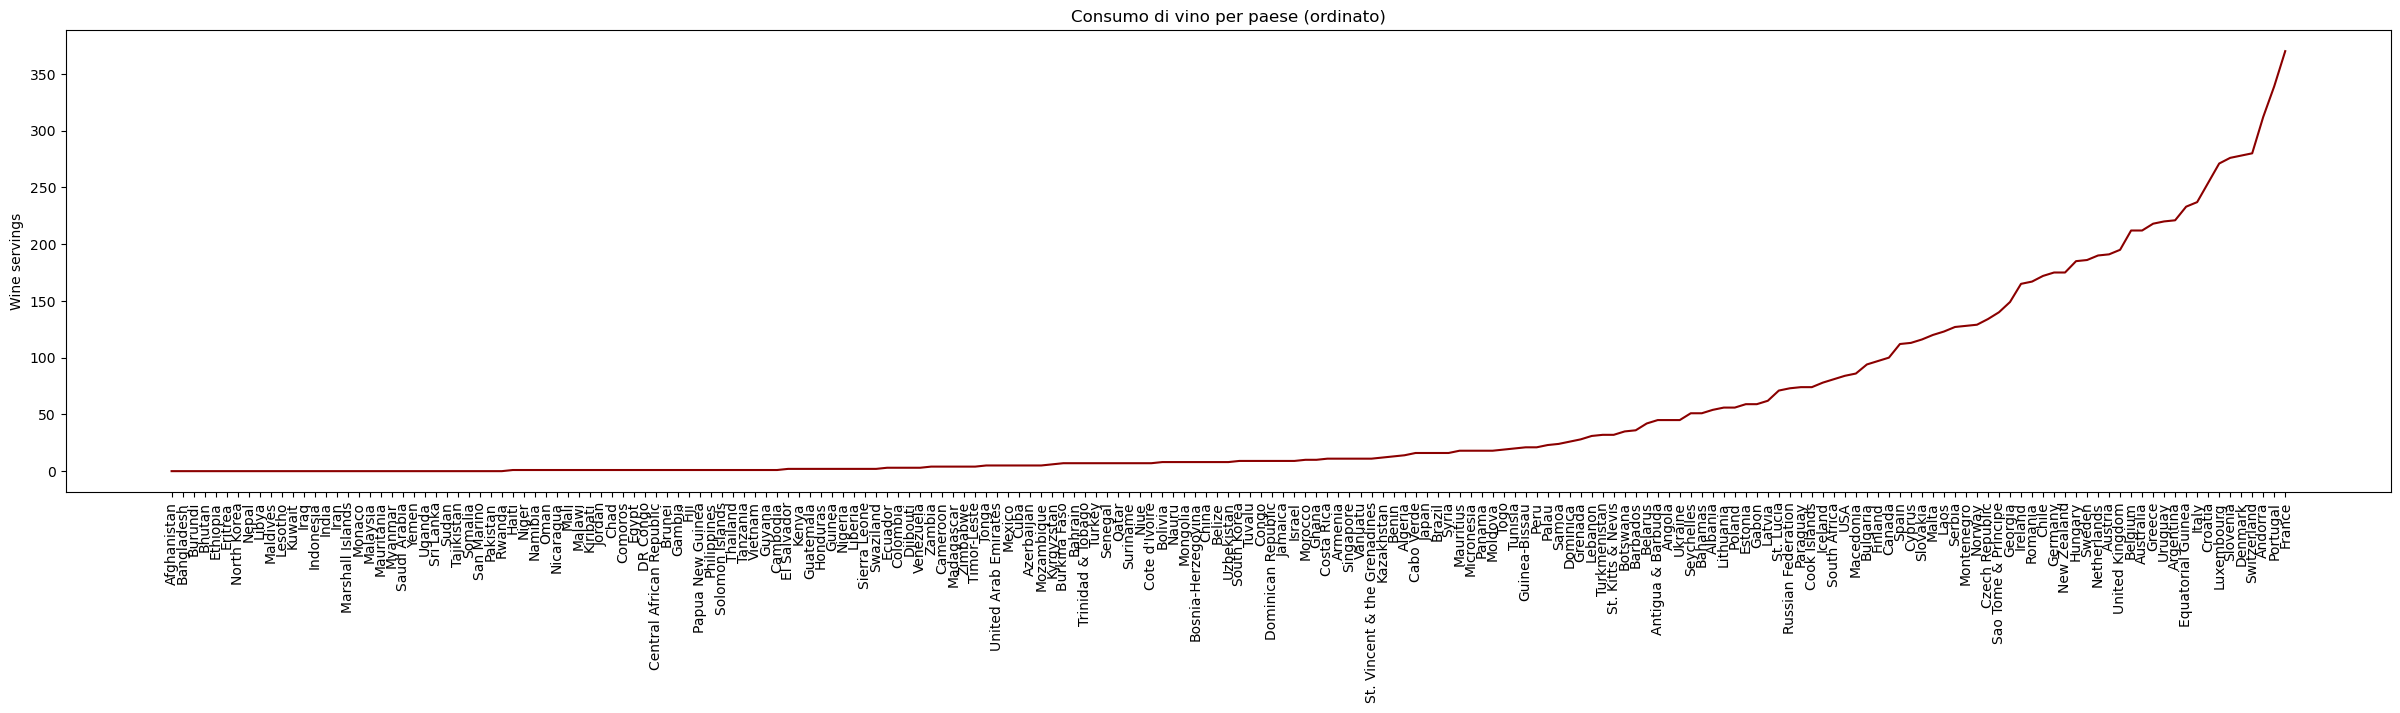

In [91]:
# Line plot del consumo di vino per Paese
vino_ord = df.sort_values('wine_servings')

plt.figure(figsize=(30,6)) 
plt.plot(vino_ord['country'], vino_ord['wine_servings'], color='darkred')
plt.xticks(rotation=90)
plt.ylabel("Wine servings")
plt.title("Consumo di vino per paese (ordinato)")
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [92]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


In [93]:
# punto 1
stipendio_medio_paese = df.groupby('job_country')["salary_year_avg"].mean().sort_values(ascending=False)
print("STIPENDIO MEDIO ANNUALE PER PAESE \n")
print(stipendio_medio_paese.head(15).to_string())

STIPENDIO MEDIO ANNUALE PER PAESE 

job_country
Belarus                     400000.000000
Russia                      292500.000000
Bahamas                     201511.619048
Dominican Republic          157500.000000
Northern Mariana Islands    155485.500000
Côte d'Ivoire               147500.000000
Namibia                     140857.142857
Sudan                       134051.577942
United States               126134.487958
Chile                       124918.454545
Canada                      123121.533477
El Salvador                 121875.000000
Ireland                     121133.443396
Sweden                      120636.617021
Australia                   118987.574324


In [94]:
# punto 2
numero_offerte_paese = df["job_country"].value_counts(ascending=True) # conto e ordino dal Paese con meno offerte a quello che ne ha di piu
print("NUMERO DI OFFERTE DI LAVORO PER PAESE \n")
print(numero_offerte_paese.head(15).to_string())

NUMERO DI OFFERTE DI LAVORO PER PAESE 

job_country
Maldives                     2
Lesotho                      3
Mauritania                   3
Bhutan                       3
Guinea                       4
Northern Mariana Islands     4
Gambia                       5
Papua New Guinea             6
Guyana                       7
Guadeloupe                   7
Curaçao                      7
Djibouti                     8
Yemen                       10
Angola                      11
Laos                        11


In [95]:
# punto 3
stipendio_medio_paese_min = df.groupby('job_country')["salary_year_avg"].min() # Per ogni Paese prendo salario minimo
print("STIPENDIO MINIMO PER PAESE \n")
print(stipendio_medio_paese_min.head(10).to_string())
stipendio_medio_paese_max = df.groupby('job_country')["salary_year_avg"].max() # Per ogni Paese prendo salario massimo
print("\nSTIPENDIO MASSIMO PER PAESE \n")
print(stipendio_medio_paese_max.head(10).to_string())

STIPENDIO MINIMO PER PAESE 

job_country
Afghanistan         NaN
Albania         43200.0
Algeria         44100.0
Angola              NaN
Argentina       45000.0
Armenia         45000.0
Australia       20000.0
Austria         53014.0
Azerbaijan      72000.0
Bahamas        173500.0

STIPENDIO MASSIMO PER PAESE 

job_country
Afghanistan         NaN
Albania        157500.0
Algeria         45000.0
Angola              NaN
Argentina      222000.0
Armenia        128682.0
Australia      257500.0
Austria        165000.0
Azerbaijan      72000.0
Bahamas        284016.0


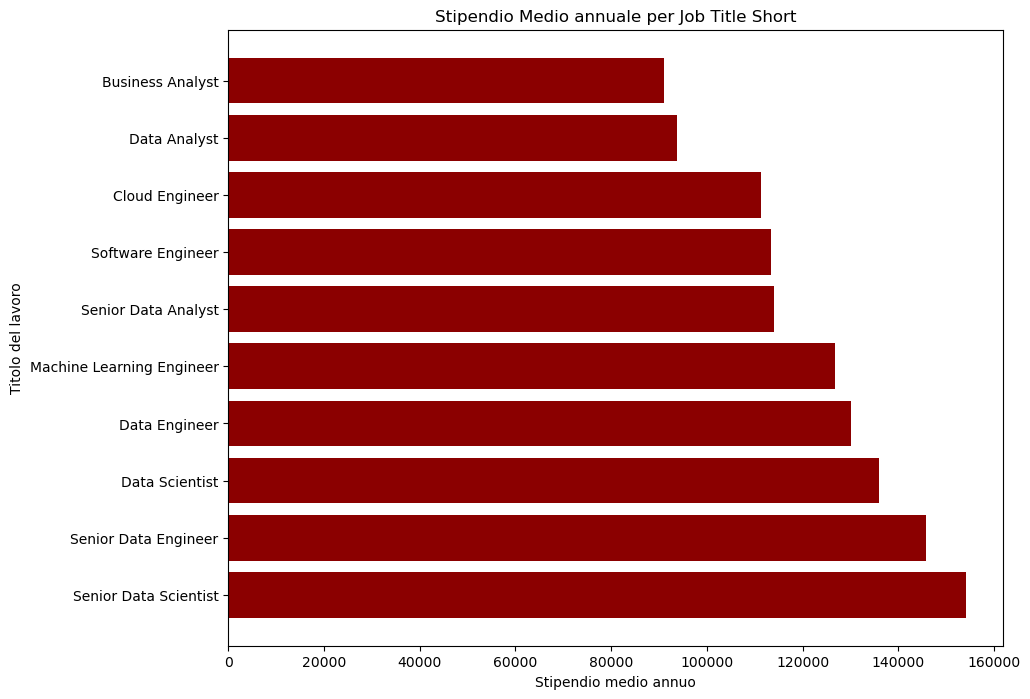

In [96]:
# Grafico a barre orizzontale

stipendio_medio_short = df.groupby("job_title_short")["salary_year_avg"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,8))
plt.barh(stipendio_medio_short.index, stipendio_medio_short.values, color = 'darkred')
plt.xlabel('Stipendio medio annuo')
plt.ylabel('Titolo del lavoro')
plt.title("Stipendio Medio annuale per Job Title Short")
plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [97]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [98]:
# punto 1
conto_medio = df.groupby('day')['total_bill'].mean()
print("Conto medio per giorno\n")
print(conto_medio.to_string())


Conto medio per giorno

day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.682742


In [99]:
# punto 2
osservazioni_tot = df["day"].value_counts()
print("Numero di osservazioni per giorno\n")
print(osservazioni_tot.to_string())

Numero di osservazioni per giorno

day
Sat     87
Sun     76
Thur    62
Fri     19


In [100]:
# punto 3
min_max = df.groupby('day')['total_bill'].agg([min, max])
print("Min e Max del conto per giorno\n")
print(min_max.to_string())

Min e Max del conto per giorno

       min    max
day              
Fri   5.75  40.17
Sat   3.07  50.81
Sun   7.25  48.17
Thur  7.51  43.11


In [101]:
# punto 4
df['conto_per_persona'] = df["total_bill"]/df["size"]
df[["total_bill", "size", "conto_per_persona"]].head() # conto totale diviso per numero di persone


,total_bill,size,conto_per_persona
0,16.99,2,8.495000
1,10.34,3,3.446667
2,21.01,3,7.003333
3,23.68,2,11.840000
4,24.59,4,6.147500


In [102]:
# punto 5
giorno_top = conto_medio.idxmax()
valore_top = conto_medio.max()

print("Giorno con il conto medio più alto:\n")
print(f"{giorno_top} con un conto medio di {valore_top:.2f}")

Giorno con il conto medio più alto:

Sun con un conto medio di 21.41


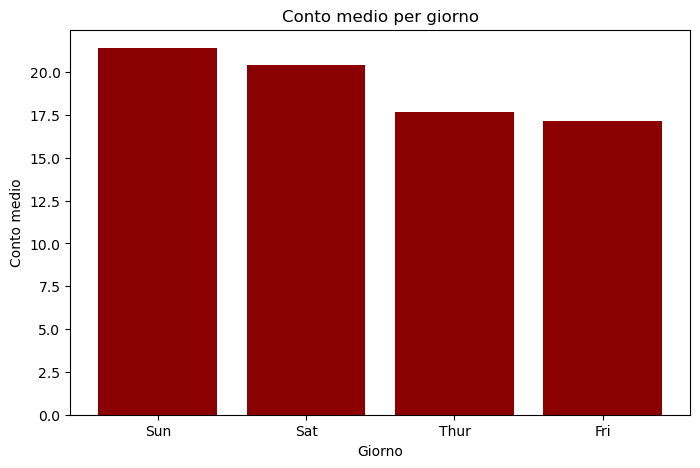

In [103]:
# Grafico a barre del conto medio per giorno (decrescente)
import matplotlib.pyplot as plt

# Ordino dal più alto al più basso
conto_medio_ordinato = conto_medio.sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(conto_medio_ordinato.index, conto_medio_ordinato.values, color="darkred")
plt.xlabel("Giorno")
plt.ylabel("Conto medio")
plt.title("Conto medio per giorno")
plt.show()